In [25]:
%matplotlib inline

import numpy as np
import torch
from mpl_toolkits import mplot3d
from torch import nn
from d2l import torch as d2l

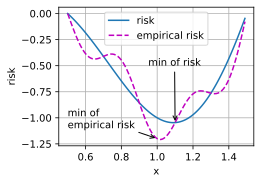

In [ ]:
# Risk & Empirical Risk

def risk(
    x: torch.Tensor,
) -> torch.Tensor:
    return x * torch.cos(
        np.pi * x
    )
    
def empirical_risk(
    x: torch.Tensor,
) -> torch.Tensor:
    return (
        risk(x)
        + 0.2 * torch.cos(
            5 * np.pi * x
        )
    )
    
def annotate(
    text: str,
    xy: tuple[float, float],
    xytext: tuple[float, float],
) -> None:
    d2l.plt.gca().annotate(
        text,
        xy=xy,
        xytext=xytext,
        arrowprops={
            "arrowstyle": "->",
        },
    )
    
x = torch.arange(
    0.5,
    1.5,
    0.01,
)

d2l.set_figsize(
    (4.5, 2.5)
)

d2l.plot(
    x,
    [
        risk(x),
        empirical_risk(x),
    ],
    xlabel="x",
    ylabel="risk",
    legend=[
        "risk",
        "empirical risk",
    ],
)

annotate(
    "min of\nempirical risk",
    (1.0, -1.2),
    (0.5, -1.1),
)

annotate(
    "min of risk",
    (1.1, -1.05),
    (0.95, -0.5),
)

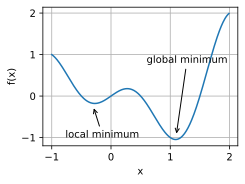

In [27]:
# Local Minimum & Global Minimum

x = torch.arange(
    -1.0,
    2.0,
    0.01,
)

d2l.plot(
    x,
    [risk(x)],
    xlabel="x",
    ylabel="f(x)",
)

annotate(
    "local minimum",
    (-0.3, -0.25),
    (-0.77, -1.0),
)

annotate(
    "global minimum",
    (1.1, -0.95),
    (0.6, 0.8),
)

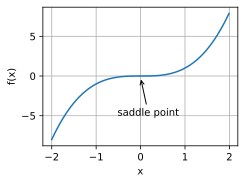

In [28]:
# One-Dimensional Saddle Point

x = torch.arange(
    -2.0,
    2.0,
    0.01,
)

d2l.plot(
    x,
    [x**3],
    xlabel="x",
    ylabel="f(x)",
)

annotate(
    "saddle point",
    (0.0, -0.2),
    (-0.52, -5.0),
)

Text(0.5, 0, 'f(x, y)')

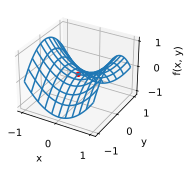

In [29]:
# High-Dimensional Saddle Point

x_grid, y_grid = torch.meshgrid(
    torch.linspace(
        -1.0,
        1.0,
        101,
    ),
    torch.linspace(
        -1.0,
        1.0,
        101,
    ),
    indexing="ij",
)

z_grid = (
    x_grid**2
    - y_grid**2
)

ax = d2l.plt.figure().add_subplot(
    111,
    projection="3d",
)

ax.plot_wireframe(
    x_grid.numpy(),
    y_grid.numpy(),
    z_grid.numpy(),
    rstride=10,
    cstride=10,
)

ax.scatter(
    0,
    0,
    0,
    color="red",
)

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x, y)")

Gradient at x=4: 0.0013408660888671875


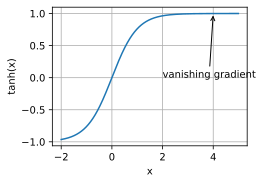

In [30]:
# Vanishing Gradient

x = torch.arange(
    -2.0,
    5.0,
    0.01,
)

d2l.plot(
    x,
    [torch.tanh(x)],
    xlabel="x",
    ylabel="tanh(x)",
)

annotate(
    "vanishing gradient",
    (4.0, 1.0),
    (2.0, 0.0),
)

x_at_4 = torch.tensor(
    4.0
)

gradient_at_4 = (
    1
    - torch.tanh(x_at_4) ** 2
)

print(
    "Gradient at x=4:",
    gradient_at_4.item(),
)

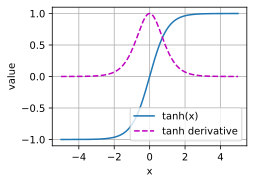

In [31]:
# Tanh와 Derivative 비교

x = torch.arange(
    -5.0,
    5.0,
    0.01,
)

tanh_values = torch.tanh(x)

tanh_gradients = (
    1
    - tanh_values**2
)

d2l.plot(
    x,
    [
        tanh_values,
        tanh_gradients,
    ],
    xlabel="x",
    ylabel="value",
    legend=[
        "tanh(x)",
        "tanh derivative",
    ],
)